<a href="https://colab.research.google.com/github/gabrielcord/recpad20252/blob/main/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Backpropagation

**Aluno:** Gabriel Cordeiro

**Disciplina:** Redes Neurais Artificiais

**Semestre:** 2026/1

## Enunciado

Você deve implementar e testar um Multi Layer Perceptron (MLP) e comprar o resultado dele com o implementado no Scikit-Learn.

O seu MLP deve aceitar parâmetros para definir a quantidade de camadas, assim como a quantidade de neurônios em cada camada e a função de ativação que será utilizada em cada camada.

## Solução

### Preparação do dataset

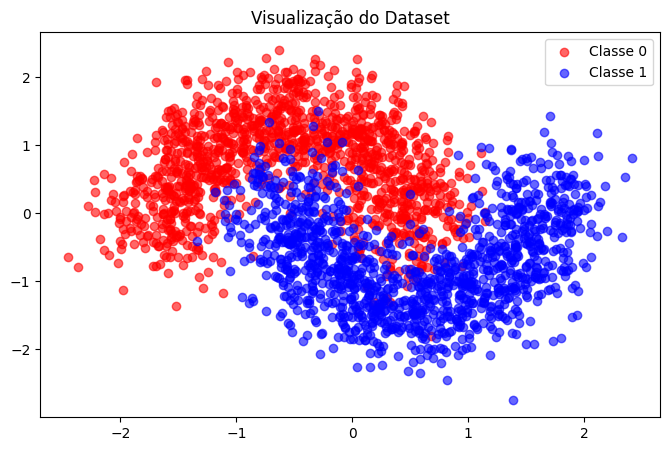

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=2_500, noise=0.25, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Classe 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Classe 1', alpha=0.6)
plt.title("Visualização do Dataset")
plt.legend()
plt.show()

### Implementação do MLP

In [94]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class MultiLayerPerceptron(BaseEstimator, ClassifierMixin):

  _activations = {
      'tanh': (np.tanh, lambda x: 1 - np.tanh(x)**2),
      'relu': (lambda x: np.maximum(0, x), lambda x: (x > 0).astype(float))
  }

  def __init__(self, hidden_layers=(32, 16), activation='tanh', max_iter=10_000,
               learning_rate=0.001, random_state=42):
    self.hidden_layers = hidden_layers
    self.func, self.deriv = self._activations[activation]
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.random_state = random_state
    self.loss_history = []

  def _include_bias(self, X):
    return np.hstack((np.ones((X.shape[0], 1)), X))

  def fit(self, X, y):
    if len(y.shape) == 1:
      y = y.reshape(-1, 1)

    # Cria o gerador de números aleatórios com a seed fornecida
    rng = np.random.default_rng(self.random_state)

    self.Ws = []
    prev = X.shape[1]
    self.loss_history = []

    # Inicialização dos pesos usando o gerador 'rng'
    for n in self.hidden_layers:
      # Uniforme entre -1 e 1
      self.Ws.append(rng.uniform(-1, 1, (prev + 1, n)))
      prev = n
    self.Ws.append(rng.uniform(-1, 1, (prev + 1, y.shape[1])))

    for _ in range(self.max_iter):
      # Forward Pass
      self.A, self.Z = [], []
      aux = X.copy()
      for W in self.Ws[:-1]:
        self.A.append(self._include_bias(aux))
        self.Z.append(self.A[-1] @ W)
        aux = self.func(self.Z[-1])

      self.A.append(self._include_bias(aux))
      self.Z.append(self.A[-1] @ self.Ws[-1])

      # Registro da Loss (MSE)
      error = np.mean((self.Z[-1] - y)**2)
      self.loss_history.append(error)

      # Backward Pass
      delta = self.Z[-1] - y
      grads = [self.A[-1].T @ delta]
      for i in range(len(self.Ws)-1, 0, -1):
        delta = (delta @ self.Ws[i][1:].T) * self.deriv(self.Z[i-1])
        grads.insert(0, self.A[i-1].T @ delta)

      # Atualização de pesos
      for i in range(len(self.Ws)):
        self.Ws[i] -= grads[i] * self.learning_rate

    return self

  def predict(self, X):
    aux = X.copy()
    for W in self.Ws[:-1]:
      aux = self.func(self._include_bias(aux) @ W)
    logits = self._include_bias(aux) @ self.Ws[-1]
    return np.sign(logits)

### Treinamento do MLP implementado

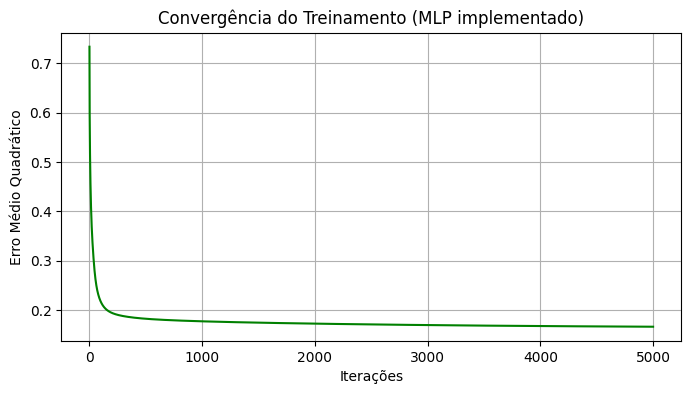

In [95]:
mlp = MultiLayerPerceptron(
    hidden_layers=(16, 8),
    activation='tanh',
    max_iter=5_000,
    learning_rate=0.0001,
    random_state=42
)

y_train_mlp = np.where(y_train == 0, -1, 1)
mlp.fit(X_train, y_train_mlp)

plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_history, color='green')
plt.title("Convergência do Treinamento (MLP implementado)")
plt.xlabel("Iterações")
plt.ylabel("Erro Médio Quadrático")
plt.grid(True)
plt.show()

### Predição com MLP implementado

Acurácia (MLP implementado): 93.20%


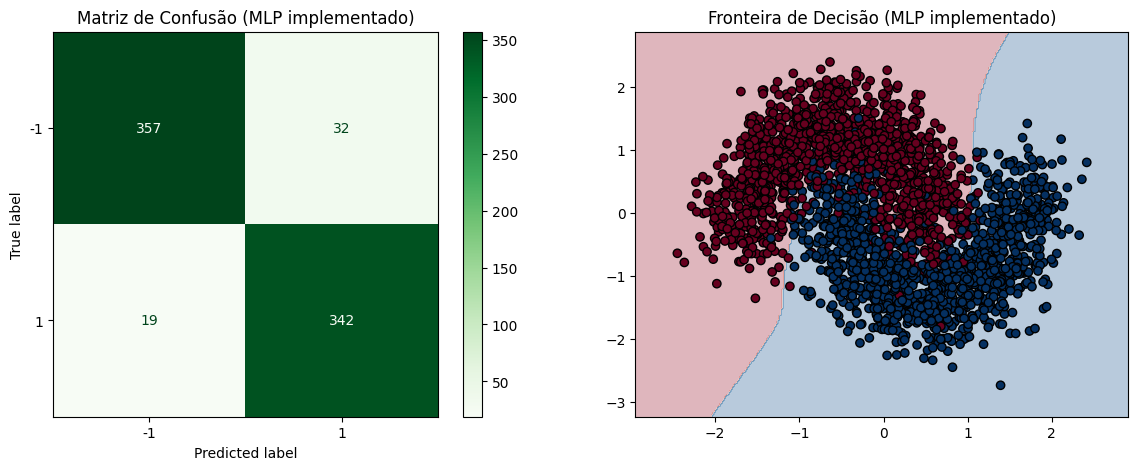

In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = mlp.predict(X_test)

y_test_mlp = np.where(y_test == 0, -1, 1)
acc = accuracy_score(y_test_mlp, y_pred)
print(f"Acurácia (MLP implementado): {acc:.2%}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Matriz de Confusão
cm = confusion_matrix(y_test_mlp, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
disp.plot(ax=ax[0], cmap=plt.cm.Greens)
ax[0].set_title("Matriz de Confusão (MLP implementado)")

# Plot B: Fronteira de Decisão
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
ax[1].scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu)
ax[1].set_title("Fronteira de Decisão (MLP implementado)")

plt.show()

### Treinamento do benchmark sklearn

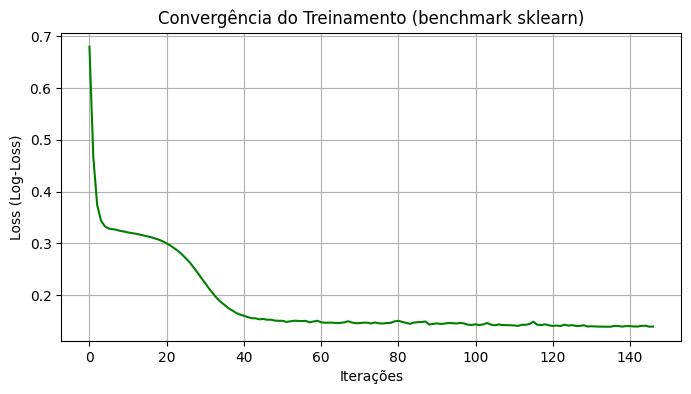

In [97]:
from sklearn.neural_network import MLPClassifier

benchmark = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='tanh',
    max_iter=5_000,
    learning_rate_init=0.005,
    random_state=42,
)

benchmark.fit(X_train, y_train)

plt.figure(figsize=(8, 4))
plt.plot(benchmark.loss_curve_, color='green')
plt.title("Convergência do Treinamento (benchmark sklearn)")
plt.xlabel("Iterações")
plt.ylabel("Loss (Log-Loss)")
plt.grid(True)
plt.show()

### Predição com benchmark sklearn

Acurácia (benchmark sklearn): 93.07%


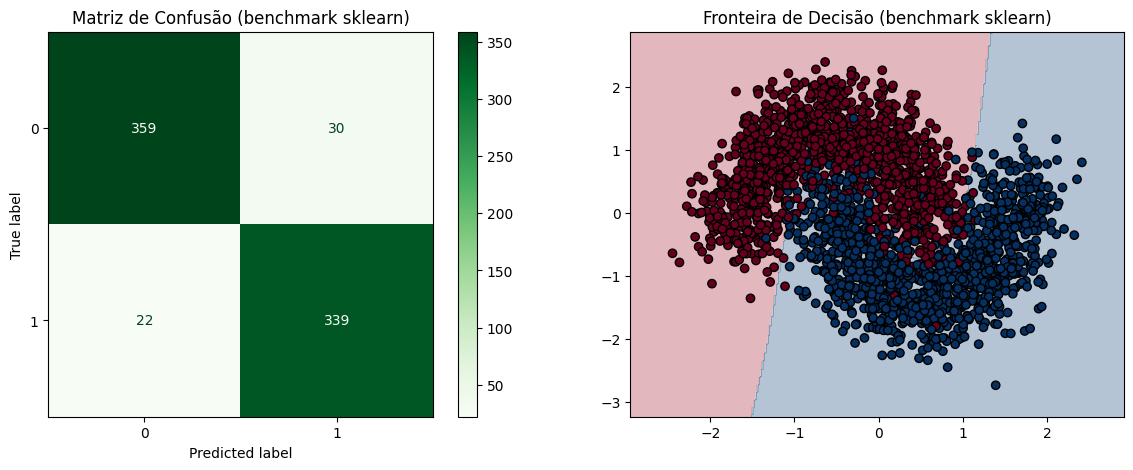

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

pred_sk = benchmark.predict(X_test)
acc_sk = accuracy_score(y_test, pred_sk)
print(f"Acurácia (benchmark sklearn): {acc_sk:.2%}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Matriz de Confusão do Scikit-Learn
cm_sk = confusion_matrix(y_test, pred_sk)
disp_sk = ConfusionMatrixDisplay(confusion_matrix=cm_sk, display_labels=[0, 1])
disp_sk.plot(ax=ax[0], cmap=plt.cm.Greens)
ax[0].set_title("Matriz de Confusão (benchmark sklearn)")

# Plot B: Fronteira de Decisão do Scikit-Learn
Z_sk = benchmark.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax[1].contourf(xx, yy, Z_sk, alpha=0.3, cmap=plt.cm.RdBu, vmin=0, vmax=1)
ax[1].scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu, vmin=0, vmax=1)
ax[1].set_title("Fronteira de Decisão (benchmark sklearn)")

plt.show()

### Comparação

Ambos os modelos apresentaram acurácias similares e fronteiras de decisão visualmente semelhantes, o que sugere que a implementação do algoritmo de backpropagation está correta.

O modelo do Scikit-Learn exigiu uma taxa de aprendizado maior (0.005) para convergir, enquanto o MLP implementado apresentou estabilidade com uma taxa mais conservadora (0.0001).


O tempo de treinamento também foi distinto: o MLP implementado levou aproximadamente 40 segundos para treinar, enquanto o modelo do Scikit-learn treinou em apenas 1 segundo.